# Multi-Objective Integer Programming Approach to Loan Portfolio Selection under Credit Risk Constraints.

## Overview

This notebook implements an **end-to-end credit risk pipeline** on the LendingClub dataset (2007–2018 Q4, ~2.2 M accepted loans). The work is divided into two major phases:

**Phase 1 — Probability-of-Default (PD) Model**  
A CatBoost gradient-boosted classifier is trained to predict the likelihood that a borrower will default (`Charged Off`) versus fully repay the loan (`Fully Paid`). The pipeline covers data cleaning, leakage removal, feature engineering, time-series–aware splitting, model training with early stopping, threshold-independent evaluation (AUC-ROC, AUC-PR, Brier score), calibration analysis.

**Phase 2 — Portfolio Optimisation with Binary Integer Programming (BIP)**  
Model predictions (PD, Expected Loss, Expected Return) are stored in an Oracle Autonomous Database. A Pyomo-based ε-constraint BIP solver then selects the return-maximising subset of loans subject to risk, budget, and diversification constraints. The full Pareto frontier is traced and benchmarked against a traditional PD-threshold heuristic to quantify the optimality gap.

---

**Dataset:** LendingClub Accepted Loans 2007–2018 Q4 (`accepted_2007_to_2018Q4.csv.gz`)  
**Environment:** Kaggle Notebooks (Python 3.12)  
**Key Libraries:** pandas, numpy, CatBoost, scikit-learn, Pyomo + HiGHS, oracledb, matplotlib


## 1. Environment Setup & Data Loading

Import core scientific libraries and list all files available in the Kaggle input directory. Then load the raw LendingClub dataset (~2.2 M rows × 150 columns) into memory.


In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/reshmarajeshdev/oracle-wallet/ojdbc.properties
/kaggle/input/datasets/reshmarajeshdev/oracle-wallet/README
/kaggle/input/datasets/reshmarajeshdev/oracle-wallet/cwallet.sso
/kaggle/input/datasets/reshmarajeshdev/oracle-wallet/keystore.jks
/kaggle/input/datasets/reshmarajeshdev/oracle-wallet/ewallet.p12
/kaggle/input/datasets/reshmarajeshdev/oracle-wallet/tnsnames.ora
/kaggle/input/datasets/reshmarajeshdev/oracle-wallet/truststore.jks
/kaggle/input/datasets/reshmarajeshdev/oracle-wallet/ewallet.pem
/kaggle/input/datasets/reshmarajeshdev/oracle-wallet/sqlnet.ora
/kaggle/input/datasets/wordsforthewise/lending-club/rejected_2007_to_2018Q4.csv.gz
/kaggle/input/datasets/wordsforthewise/lending-club/accepted_2007_to_2018Q4.csv.gz
/kaggle/input/datasets/wordsforthewise/lending-club/accepted_2007_to_2018q4.csv/accepted_2007_to_2018Q4.csv
/kaggle/input/datasets/wordsforthewise/lending-club/rejected_2007_to_2018q4.csv/rejected_2007_to_2018Q4.csv


In [2]:
import pandas as pd
raw = pd.read_csv("/kaggle/input/datasets/wordsforthewise/lending-club/accepted_2007_to_2018Q4.csv.gz", low_memory=False)
print(f'Raw shape: {raw.shape[1]}')

Raw shape: 151


## 2. Target Engineering

Only loans with a **terminal outcome** are useful for supervised learning. Loans still in repayment (`Current`, `In Grace Period`, `Late`) have an unknown final status and must be excluded.

Retain only:
- **Fully Paid** → `default = 0`
- **Charged Off** → `default = 1`

This produces a binary classification target. The resulting class distribution is printed to verify the level of imbalance.

In [3]:
df = raw[raw['loan_status'].isin(['Fully Paid', 'Charged Off'])].copy()
df['default'] = df['loan_status'].map({'Fully Paid': 0, 'Charged Off': 1})

# Build the LGD-input frame in lock-step with df (same rows, same index)
lgd_inputs = df[['loan_status', 'funded_amnt',
                 'total_rec_prncp', 'recoveries']].copy()

print(df['default'].value_counts(normalize=True).rename({0:'Fully Paid', 1:'Charged Off'}).to_string())

default
Fully Paid     0.800374
Charged Off    0.199626


## 3. Feature Selection

Before modelling, we remove columns that would either leak future information or carry no predictive value.

### 3a. Remove data-leakage and redundant columns

**Data leakage** occurs when the model sees information that would not be available at loan origination time. Examples include `total_pymnt` (total payments received), `recoveries` (post-charge-off collections), and `last_pymnt_d` (date of last payment) — all of which are determined by the loan's outcome.

**Redundant columns** like `id`, `url`, `emp_title`, and `zip_code` are either unique identifiers with no generalisable signal or too high-cardinality to be useful without heavy feature engineering. The `installment` column is also dropped here because it is a deterministic function of `loan_amnt`, `int_rate`, and `term` — keeping it would introduce multicollinearity and later we re-derive it explicitly as a feature.

In [4]:
leakage_cols = [
    'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv',
    'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries',
    'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt',
    'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low',
    'debt_settlement_flag', 'hardship_flag', 'loan_status', 'settlement_date', 
    'debt_settlement_flag_date', 'hardship_start_date', 'hardship_end_date', 
    'settlement_status', 'settlement_amount','hardship_reason', 'hardship_status',
    'hardship_loan_status','payment_plan_start_date', 'sec_app_earliest_cr_line'
]
redundant_cols = ['id', 'desc', 'url', 'title', 'emp_title', 'zip_code', 'policy_code', 'member_id', 'installment']

df.drop(columns=leakage_cols + redundant_cols, inplace=True, errors='ignore')
print(f'After leakage/redundant removal: {df.shape[1]} columns')

After leakage/redundant removal: 115 columns


 ### 3b. Sort the data w.r.t issue_d for time series validation

The `issue_d` column records the month the loan was funded. We parse it to datetime, sort the entire dataset chronologically, and then **drop** `issue_d` itself. Sorting is essential because we later use a **time-series split** (train on the past, test on the future) rather than a random split. Dropping the date column prevents the model from memorising calendar effects that might not generalise.

In [5]:
df['issue_d'] = pd.to_datetime(df['issue_d'], format='%b-%Y')

# Sort df by issue date; align lgd_inputs to the same row order
df = df.sort_values('issue_d')
lgd_inputs = lgd_inputs.reindex(df.index)

# Now reset both indices together so .iloc[:split_idx] means the same rows in both
df         = df.reset_index(drop=True)
lgd_inputs = lgd_inputs.reset_index(drop=True)

df.drop(columns=['issue_d'], inplace=True)

### 3c. Drop zero/near-zero variance columns

Columns where every row has the same value (or only one unique value) carry zero information and cannot contribute to any split in a tree-based model. Removing them reduces dimensionality without any loss of signal.

In [6]:
low_var = [c for c in df.columns if df[c].nunique() <= 1]
df.drop(columns=low_var, inplace=True)
print(f'Dropped low-variance: {low_var}')
print(f'Final column count: {df.shape[1]}')

Dropped low-variance: ['pymnt_plan', 'next_pymnt_d', 'hardship_type', 'deferral_term', 'hardship_length']
Final column count: 109


## 4. Data Preprocessing & Feature Engineering

Raw LendingClub data contains many fields stored as strings (e.g. `'15.24%'`, `' 36 months'`, `'10+ years'`). This section converts them to proper numeric types, creates domain-motivated interaction features, identifies categoricals for CatBoost, and handles missing values.




### 4a. Parse numeric-string fields
Several important numeric columns arrive as formatted strings:

| Column | Raw example | Transformation |
|--------|------------|----------------|
| `int_rate` | `'15.24%'` | Strip `%`, cast to float |
| `revol_util` | `'73.5%'` | Strip `%`, cast to float |
| `term` | `' 36 months'` | Extract digits, cast to float |
| `emp_length` | `'10+ years'` | Map to integer 0–10 |
| `earliest_cr_line` | `'Jan-2003'` | Convert to `credit_age_months` relative to Dec 2018 |



In [7]:

if df['int_rate'].dtype == object:
    df['int_rate'] = df['int_rate'].str.replace('%', '').astype(float)

if 'revol_util' in df.columns and df['revol_util'].dtype == object:
    df['revol_util'] = df['revol_util'].str.replace('%', '').astype(float)

if df['term'].dtype == object:
    df['term'] = df['term'].str.extract(r'(\d+)').astype(float)

if 'emp_length' in df.columns and df['emp_length'].dtype == object:
    df['emp_length'] = (
        df['emp_length']
        .str.replace(r'10\+ years', '10', regex=True)
        .str.replace('< 1 year', '0', regex=True)
        .str.extract(r'(\d+)')
        .astype(float)
    )

if 'earliest_cr_line' in df.columns:
    df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'], format='%b-%Y', errors='coerce')
    REFERENCE_DATE = pd.Timestamp('2018-12-31')
    df['credit_age_months'] = (
        (REFERENCE_DATE - df['earliest_cr_line']) / pd.Timedelta(days=30)
    ).round()
    df.drop(columns=['earliest_cr_line'], inplace=True)

print('String parsing complete.')

String parsing complete.


### 4b. Feature Engineering

We create several domain-motivated features designed to capture a borrower's financial stress more precisely than any single raw column:

- **`loan_to_income`** — Ratio of the loan amount to annual income. Higher values indicate the borrower is taking on a larger obligation relative to their earnings.
- **`est_installment`** — Estimated monthly payment derived from the standard amortisation formula using `loan_amnt`, `int_rate`, and `term`. This replaces the raw `installment` column that was dropped earlier to avoid collinearity.
- **`payment_to_income`** — Monthly payment burden: estimated installment divided by monthly income. A direct proxy for how stretched the borrower's monthly budget is.
- **`shock_dti`** — "Shock" debt-to-income ratio. The dataset's `dti` reflects existing debts; `shock_dti` adds the new loan's installment to get the **post-origination** DTI, simulating the real burden after approval.
- **`dti_x_loan_to_inc`** — Interaction between DTI and loan-to-income. Captures borrowers who are both highly leveraged *and* taking a disproportionately large loan.


In [8]:

# Loan-to-income ratio: higher means borrower is more stretched
# Low ratio → borrower can likely repay easily
df['loan_to_income'] = df['loan_amnt'] / (df['annual_inc'].clip(lower=1))

# Monthly payment burden proxy: installment / monthly income
# (installment was dropped as correlated, re-derive roughly)
if 'installment' not in df.columns:
    # approximate monthly payment via amortisation formula
    r = (df['int_rate'] / 100) / 12
    n = df['term']
    df['est_installment'] = np.where(
        r == 0,
        df['loan_amnt'] / n,
        df['loan_amnt'] * r * (1 + r)**n / ((1 + r)**n - 1)
    )
    df['payment_to_income'] = df['est_installment'] / (df['annual_inc'].clip(lower=1) / 12)

# "Shock" Debt-to-Income (DTI)
# The provided DTI is usually 'current'. This adds the new loan burden.
if 'est_installment' in df.columns:
    # monthly_inc = annual_inc / 12
    df['shock_dti'] = (df['dti'] * (df['annual_inc']/12) + df['est_installment']) / (df['annual_inc']/12 + 1)

# Debt Burden interaction
df['dti_x_loan_to_inc'] = df['dti'] * df['loan_to_income']


print('Feature engineering complete.')
print(f'Total features (incl. target): {df.shape[1]}')

Feature engineering complete.
Total features (incl. target): 114


### 4c. Identify Categorical Features

CatBoost handles categorical variables **natively** using ordered target statistics — no manual one-hot encoding is needed. We identify all remaining `object`/`category` columns and ensure they are clean string types with NaN replaced by `'Unknown'`.


In [9]:
TARGET = 'default'

cat_features = df.select_dtypes(include=['object', 'category']).columns.tolist()
cat_features = [c for c in cat_features if c != TARGET]


# Ensure object dtypes are clean strings (fill NaN with 'Unknown')
for col in cat_features:
    df[col] = df[col].fillna('Unknown').astype(str)

print(f'Categorical features ({len(cat_features)}): {cat_features}')

Categorical features (10): ['grade', 'sub_grade', 'home_ownership', 'verification_status', 'purpose', 'addr_state', 'initial_list_status', 'application_type', 'verification_status_joint', 'disbursement_method']


### 4d. Missing-Value Handling for Numeric Features

CatBoost handles missing numeric values internally without requiring imputation; the algorithm treats NaN as
smaller than any observed value for the feature when evaluating split candidates. For every numeric column that has missing values, we also create a binary **`_was_missing`** flag (0 or 1) so the model can learn whether the missingness itself is informative (e.g., a missing `mths_since_last_delinq` often means the borrower has never been delinquent — a positive signal).


In [10]:
# 1. Identify numeric features
num_features = [c for c in df.select_dtypes(include=[np.number]).columns if c != TARGET]

# 2. Create the "Is_Imputed" flags
missing_flags = {}

for col in num_features:
    if df[col].isnull().any():
        # Store the new series in a dictionary instead of the DataFrame
        missing_flags[f"{col}_was_missing"] = df[col].isnull().astype(int)

# Concatenate all new columns at once
if missing_flags:
    new_cols_df = pd.DataFrame(missing_flags, index=df.index)
    df = pd.concat([df, new_cols_df], axis=1)

print(f'Numeric features: {len(num_features)}')
print(f'New flag features created: {len([c for c in df.columns if "_was_missing" in c])}')
print(f'Remaining nulls: {df.isnull().sum().sum()}')

Numeric features: 103
New flag features created: 84
Remaining nulls: 46441127


---
## 5. Train / Test Split (Time-Series)

Instead of a random stratified split, we take the **earliest 80 %** of records as training data and the **latest 20 %** as the holdout test set. Because the data was sorted chronologically in Section 3b, this simulates real-world deployment: the model trains on historical loans and is evaluated on "future" loans it has never seen.



In [11]:
FEATURES = [c for c in df.columns if c != TARGET]
X = df[FEATURES]
y = df[TARGET]

split_idx = int(len(df) * 0.80)
X_train, y_train = X.iloc[:split_idx].copy(), y.iloc[:split_idx].copy()
X_test,  y_test  = X.iloc[split_idx:].copy(), y.iloc[split_idx:].copy()
test_df = df.iloc[split_idx:].reset_index(drop=True)

print(f'Train: {len(X_train):,}  |  Test: {len(X_test):,}')

Train: 1,076,248  |  Test: 269,062


**Loss Given Default Estimate**

The estimated LGD of 58% indicates that, conditional on default, approximately 58% of the exposure is not recovered. 
This value is consistent with typical recovery patterns observed in unsecured consumer lending and is derived using only defaulted loans to avoid bias.

An LGD of 0.58 means that for every $100 that was owed at the time of default, the lender lost $58.

Conversely, this implies a Recovery Rate of 42% ($1 - 0.58 = 0.42$). 
This 42% represents the money clawed back through:  
* Partial payments made after the loan defaulted.
* Late fees collected.
* Selling the debt to third-party collection agencies.


In [12]:
# Slice lgd_inputs by the same positions as X_train
train_lgd = lgd_inputs.iloc[:split_idx].copy()

train_lgd['total_recovery'] = (
    train_lgd['total_rec_prncp'].fillna(0) +
    train_lgd['recoveries'].fillna(0)
)
train_lgd['lgd'] = (
    1 - train_lgd['total_recovery'] / train_lgd['funded_amnt']
).clip(0, 1)

defaulted = train_lgd[train_lgd['loan_status'] == 'Charged Off']
LGD_avg = defaulted['lgd'].mean()

print(f"Estimated LGD on training-fold charge-offs: {LGD_avg:.3f}  "
      f"(n={len(defaulted):,})")

Estimated LGD on training-fold charge-offs: 0.584  (n=209,971)


---
## 6. CatBoost Model Training

### Why CatBoost?

CatBoost (Categorical Boosting) is chosen for three key reasons:

1. **Native categorical handling** — Columns like `purpose`, `home_ownership`, and `verification_status` are passed directly without one-hot encoding. CatBoost uses ordered target statistics internally, which avoids target leakage that naïve target encoding can cause.
2. **Ordered boosting** — CatBoost's training algorithm processes rows in a permutation-based order, reducing the prediction shift (overfitting) that standard gradient boosting suffers from on small-to-medium datasets.
3. **Calibrated probabilities out of the box** — Gradient-boosted trees trained with log-loss tend to produce well-calibrated probabilities without post-hoc adjustment, which matters here because the predicted PD feeds directly into the Expected Loss formula in the downstream optimizer.

### Validation Strategy

The last 10 % of the training set (chronologically) is carved out as a **validation slice** used exclusively for early stopping and for the Optuna hyperparameter search. This slice is *never* used for reporting metrics — only the held-out test set (Section 5) is used for that.

### Hyperparameters

`learning_rate`, `depth`, and `l2_leaf_reg` were tuned by Optuna over 20 trials with validation AUC as the objective; the remaining values follow CatBoost's recommended defaults for tabular classification.

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| `iterations` | 500 | Upper bound on boosting rounds; early stopping typically fires before this |
| `learning_rate` | 0.084 | Shrinkage factor applied to each new tree (**Optuna-tuned**) |
| `depth` | 8 | Depth of CatBoost's symmetric (oblivious) trees; each tree has 2⁸ = 256 leaves (**Optuna-tuned**) |
| `l2_leaf_reg` | 7.87 | L2 regularisation coefficient on leaf values (**Optuna-tuned**) |
| `bootstrap_type` | MVS | Minimum-Variance Sampling — CatBoost's recommended row sampler |
| `subsample` | 0.8 | 80 % row subsampling per tree |
| `rsm` | 0.8 | 80 % column subsampling per tree |
| `one_hot_max_size` | 10 | Categoricals with ≤10 levels are one-hot encoded; higher-cardinality features use ordered target statistics |
| `eval_metric` | AUC | Metric monitored on the validation slice for early stopping |
| `early_stopping_rounds` | 50 | Stop if validation AUC fails to improve for 50 consecutive rounds |
| `use_best_model` | True | Roll the final model back to the iteration with the best validation AUC |
| `random_seed` | 42 | Fixes the bootstrap and ordered-boosting permutations for reproducibility |

The combination of `depth=8` with a fairly strong L2 penalty of 7.87 is the Optuna search's compromise: deep enough to capture higher-order interactions between borrower features (e.g. `dti × loan_to_income × grade`), but with the leaf values shrunk hard enough that overfitting on the noisier tail of the training distribution is controlled. The train/validation/test diagnostic in Section 7d makes the resulting generalisation gap explicit.


In [13]:
!pip install catboost


In [14]:

cat_feature_indices = [X_train.columns.get_loc(c) for c in cat_features if c in X_train.columns]
SEED = 42

# Carve the last 10% of X_train (chronologically) as a validation slice
# Used ONLY for early stopping — never for reporting metrics
val_split = int(len(X_train) * 0.90)
X_tr  = X_train.iloc[:val_split]
X_val = X_train.iloc[val_split:]
y_tr  = y_train.iloc[:val_split]
y_val = y_train.iloc[val_split:]

print(f'Training rows : {len(X_tr):,}')
print(f'Val rows (ES) : {len(X_val):,}  (early-stopping monitor only)')
print(f'Test rows     : {len(X_test):,}  (held-out, never touched)')


Training rows : 968,623
Val rows (ES) : 107,625  (early-stopping monitor only)
Test rows     : 269,062  (held-out, never touched)


In [21]:
from catboost import CatBoostClassifier, Pool
import optuna
from sklearn.metrics import roc_auc_score

SEED = 42

# Build the Pools once — Optuna reuses them across all trials.
# X_tr / X_val / y_tr / y_val / cat_feature_indices come from the previous cell.
train_pool = Pool(X_tr,  label=y_tr,  cat_features=cat_feature_indices)
val_pool   = Pool(X_val, label=y_val, cat_features=cat_feature_indices)

def objective(trial):
    param = {
        "iterations":    500,
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "depth":         trial.suggest_int("depth", 4, 8),
        "l2_leaf_reg":   trial.suggest_float("l2_leaf_reg", 1e-2, 10.0, log=True),
        "eval_metric":   "AUC",
        "random_seed":   SEED,
        "verbose":       False,
        "bootstrap_type": "MVS",
        "subsample":      0.8,
        "rsm":            0.8,
    }
    gbm = CatBoostClassifier(**param)
    gbm.fit(train_pool, eval_set=val_pool,
            early_stopping_rounds=50, verbose=False)

    preds = gbm.predict_proba(val_pool)[:, 1]
    return roc_auc_score(y_val, preds)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

print("Best Parameters:", study.best_params)
# Copy these into the CB_PARAMS dict in the next cell.

[I 2026-05-14 14:24:43,180] A new study created in memory with name: no-name-36d10212-349d-45dd-9b79-2efaeb8158fe
[I 2026-05-14 14:31:40,951] Trial 0 finished with value: 0.76427273894811 and parameters: {'learning_rate': 0.0817787610476058, 'depth': 4, 'l2_leaf_reg': 0.38798063060921417}. Best is trial 0 with value: 0.76427273894811.
[I 2026-05-14 14:44:30,617] Trial 1 finished with value: 0.7668884821362222 and parameters: {'learning_rate': 0.0819279314662884, 'depth': 7, 'l2_leaf_reg': 0.11145630320503692}. Best is trial 1 with value: 0.7668884821362222.
[I 2026-05-14 14:59:58,300] Trial 2 finished with value: 0.7665211811886143 and parameters: {'learning_rate': 0.09090526569152103, 'depth': 8, 'l2_leaf_reg': 0.05266168511302857}. Best is trial 1 with value: 0.7668884821362222.
[I 2026-05-14 15:10:40,647] Trial 3 finished with value: 0.7557621124126688 and parameters: {'learning_rate': 0.012378166396916418, 'depth': 6, 'l2_leaf_reg': 0.05810705753610969}. Best is trial 1 with value:

Best Parameters: {'learning_rate': 0.08427509583766953, 'depth': 8, 'l2_leaf_reg': 7.871686736318791}


In [15]:
from catboost import CatBoostClassifier, Pool
CB_PARAMS = dict(
    iterations          = 500,      # enough room to converge — early stopping will fire
    learning_rate       = 0.084,
    depth               = 8,
    l2_leaf_reg         = 7.87,
    eval_metric         = 'AUC',
    one_hot_max_size    = 10,
    bootstrap_type        = 'MVS',
    subsample             = 0.8,         # row subsampling
    rsm                   = 0.8,  
    random_seed         = SEED,
    early_stopping_rounds = 50,      # stops when val AUC does not improve for 50 rounds
    use_best_model      = True,      # rolls back to the best checkpoint
    verbose             = 100,
)

train_pool = Pool(X_tr,   label=y_tr,   cat_features=cat_feature_indices)
val_pool   = Pool(X_val,  label=y_val,  cat_features=cat_feature_indices)
test_pool  = Pool(X_test, label=y_test, cat_features=cat_feature_indices)

final_model = CatBoostClassifier(**CB_PARAMS)
final_model.fit(train_pool, eval_set=val_pool)


print('Final model trained.')

0:	test: 0.7254339	best: 0.7254339 (0)	total: 1.14s	remaining: 9m 29s
100:	test: 0.7590266	best: 0.7590266 (100)	total: 1m 49s	remaining: 7m 11s
200:	test: 0.7638138	best: 0.7638138 (200)	total: 3m 37s	remaining: 5m 23s
300:	test: 0.7660530	best: 0.7660624 (299)	total: 5m 26s	remaining: 3m 35s
400:	test: 0.7672499	best: 0.7672499 (400)	total: 7m 13s	remaining: 1m 47s
499:	test: 0.7679135	best: 0.7679156 (497)	total: 9m 2s	remaining: 0us

bestTest = 0.7679155944
bestIteration = 497

Shrink model to first 498 iterations.
Final model trained.


---
## 7. Model Evaluation

All evaluation is performed on the **held-out test set** — the chronologically latest 20 % of the data that the model has never seen during training or early stopping.


### 7a. Threshold-Independent Metrics

We report four metrics that do not depend on choosing a classification threshold:

- **AUC-ROC** — Area under the Receiver Operating Characteristic curve. Measures the model's ability to rank defaulters above non-defaulters. A value of 0.5 indicates random guessing; 1.0 indicates perfect ranking.
- **AUC-PR** — Area under the Precision-Recall curve. More informative than AUC-ROC when classes are imbalanced, because it focuses on the minority (default) class.
- **Log-Loss** — Penalises confident wrong predictions. Lower is better.
- **Brier Score** — Mean squared error between predicted probabilities and actual outcomes. Lower values indicate better-calibrated probabilities — crucial for a PD model where the predicted probability is used directly in financial calculations.


In [16]:
from sklearn.metrics import (
    roc_auc_score, 
    average_precision_score, 
    log_loss, 
    brier_score_loss,
    RocCurveDisplay, 
    PrecisionRecallDisplay,
)

y_prob = final_model.predict_proba(test_pool)[:, 1]

auc_roc = roc_auc_score(y_test, y_prob)
auc_pr  = average_precision_score(y_test, y_prob)
ll      = log_loss(y_test, y_prob)
brier   = brier_score_loss(y_test, y_prob)

print(f'Test AUC-ROC : {auc_roc:.4f}')
print(f'Test AUC-PR  : {auc_pr:.4f}  (informative under imbalance)')
print(f'Test Log-Loss: {ll:.4f}')
print(f'Test Brier   : {brier:.4f}  (lower = better calibrated)')

Test AUC-ROC : 0.7560
Test AUC-PR  : 0.5294  (informative under imbalance)
Test Log-Loss: 0.4354
Test Brier   : 0.1390  (lower = better calibrated)


### 7b. ROC Curve & Precision-Recall Curve

Visual diagnostics for the model's discrimination ability:

- **ROC Curve (left):** Plots True Positive Rate vs False Positive Rate at every threshold. The dashed diagonal represents a random classifier. The further the curve bows toward the top-left corner, the better the model.
- **PR Curve (right):** Plots Precision vs Recall. The horizontal red dashed line shows the baseline precision (= dataset default rate). A useful model's curve should stay well above this baseline.


### 7b. ROC Curve & PR Curve

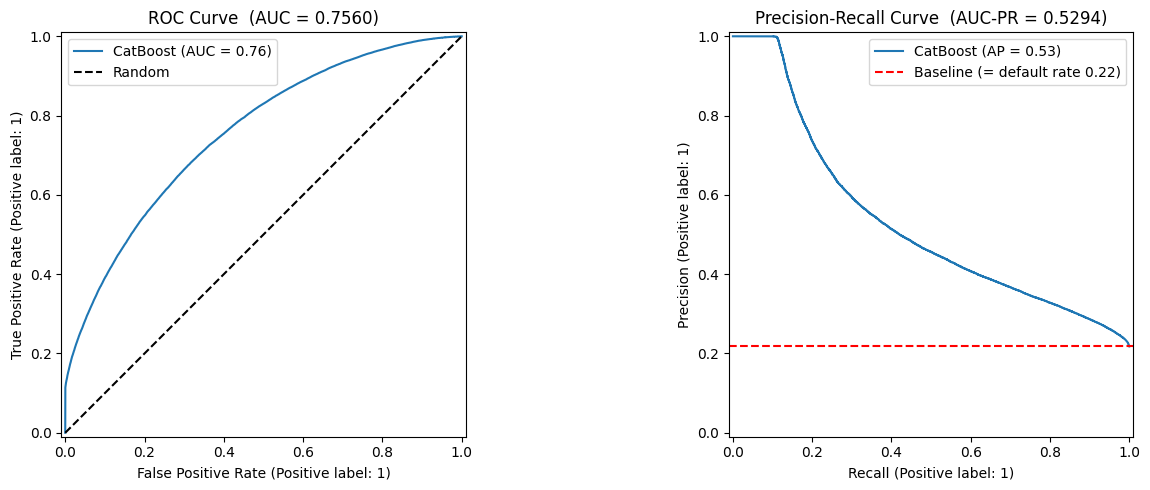

In [17]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[0], name='CatBoost')
axes[0].plot([0, 1], [0, 1], 'k--', label='Random')
axes[0].set_title(f'ROC Curve  (AUC = {auc_roc:.4f})')
axes[0].legend()

PrecisionRecallDisplay.from_predictions(y_test, y_prob, ax=axes[1], name='CatBoost')
baseline = y_test.mean()
axes[1].axhline(baseline, color='red', linestyle='--', label=f'Baseline (= default rate {baseline:.2f})')
axes[1].set_title(f'Precision-Recall Curve  (AUC-PR = {auc_pr:.4f})')
axes[1].legend()

plt.tight_layout()
plt.savefig("roc_pr_curves.png", dpi=300, bbox_inches="tight",
            facecolor="white", transparent=False)
plt.show()


### 7c. Calibration Curve

For a **Probability of Default** model, raw discrimination is not enough — the predicted probabilities must be **well-calibrated**. A predicted PD of 15 % should correspond to roughly 15 % of those borrowers actually defaulting.

A perfectly calibrated model's curve lies on the diagonal. The **Brier score** quantifies calibration quality (lower = better).


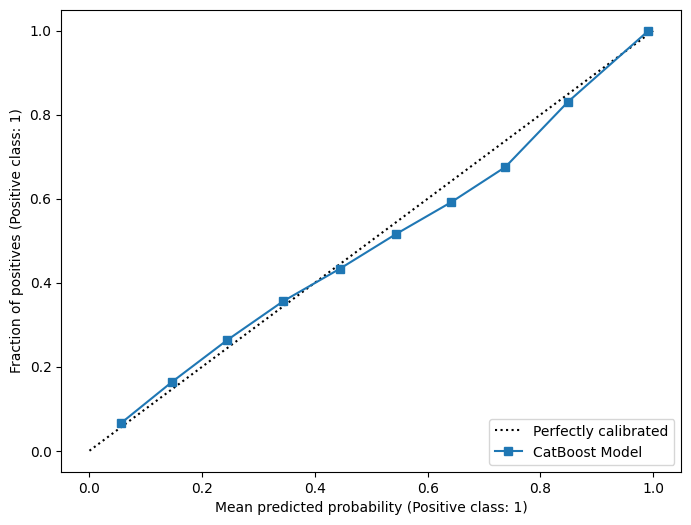

Brier Score: 0.1390


In [19]:
from sklearn.calibration import  CalibrationDisplay
from sklearn.metrics import brier_score_loss

# 1. Generate probabilities
y_prob = final_model.predict_proba(test_pool)[:, 1]

# 2. Plot calibration curve
fig, ax = plt.subplots(figsize=(8, 6))
CalibrationDisplay.from_predictions(y_test, y_prob, n_bins=10, name="CatBoost Model", ax=ax)
plt.savefig("calibration_curve.png", dpi=300, bbox_inches="tight",
            facecolor="white", transparent=False)
plt.show()

# 3. Brier score 
print(f"Brier Score: {brier:.4f}")


### 7d. Train vs Validation vs Test — Overfitting Diagnostic

Sections 7a–7c reported every metric on the held-out **test** set only. That is the right number to *quote*, but on its own it cannot tell us **why** the model achieved it — a test AUC of 0.75 can come from a well-regularised model that genuinely captured signal, or from a model that overfit the training set and got lucky on the test draw. To separate the two stories, re-score the same `final_model` on all three splits.

**What to look for in the table below.**

* **AUC-ROC and AUC-PR**: positive train − test gaps. A gap below ≈ 0.03 is considered normal for tabular gradient boosting; gaps above ≈ 0.10 are a sign that the model has memorised idiosyncratic training noise.
* **Log-Loss and Brier**: *negative* train − test gaps (training loss should be lower than test loss). A large negative gap on these — say Brier 0.08 on train versus 0.14 on test — points to the same overfit, with the additional implication that the predicted probabilities are over-confident on training points. Since the downstream optimizer treats predicted PDs as fixed inputs to the Expected Loss formula, miscalibration of this kind would propagate directly into portfolios that quietly carry more risk than the ε constraint was supposed to allow.
* **Validation row**: the chronological 10 % slice used for early stopping. It is technically "seen" by training (since it determines when to stop), so its metrics sit between train and test rather than serving as an independent estimate of generalisation. 



In [20]:
# === Evaluate on Train / Validation / Test ===
# Re-score every split with the *final* (early-stopped) model.
# Validation here = the 10 % chronological slice used for early stopping,
# so it is technically 'seen' by the training process but never gradient-fit.

from sklearn.metrics import (
    roc_auc_score, average_precision_score, log_loss, brier_score_loss
)
import pandas as pd

def _metrics(model, pool, y_true):
    p = model.predict_proba(pool)[:, 1]
    return {
        'AUC-ROC' : roc_auc_score(y_true, p),
        'AUC-PR'  : average_precision_score(y_true, p),
        'Log-Loss': log_loss(y_true, p),
        'Brier'   : brier_score_loss(y_true, p),
    }

results = pd.DataFrame({
    'Train (X_tr)'      : _metrics(final_model, train_pool, y_tr),
    'Validation (X_val)': _metrics(final_model, val_pool,   y_val),
    'Test (held-out)'   : _metrics(final_model, test_pool,  y_test),
})

# Generalisation gap: train minus test. Positive on AUC-style metrics,
# *negative* on loss-style metrics, both indicate overfitting.
gap = (results['Train (X_tr)'] - results['Test (held-out)']).rename(
    'Gap (Train − Test)'
)
results = pd.concat([results, gap.to_frame().T]).round(4)

print(results)


                    Train (X_tr)  Validation (X_val)  Test (held-out)  \
AUC-ROC                   0.7887              0.7679           0.7560   
AUC-PR                    0.5609              0.6054           0.5294   
Log-Loss                  0.3807              0.4518           0.4354   
Brier                     0.1178              0.1456           0.1390   
Gap (Train − Test)           NaN                 NaN              NaN   

                    AUC-ROC  AUC-PR  Log-Loss   Brier  
AUC-ROC                 NaN     NaN       NaN     NaN  
AUC-PR                  NaN     NaN       NaN     NaN  
Log-Loss                NaN     NaN       NaN     NaN  
Brier                   NaN     NaN       NaN     NaN  
Gap (Train − Test)   0.0327  0.0315   -0.0547 -0.0211  


---
## 8. Database Storage & Optimisation Dependencies

This section transitions from the ML modelling phase to the **portfolio optimisation** phase. We install the required packages (`oracledb` for Oracle Autonomous Database connectivity, `pyomo` + `highspy` for mathematical programming) and verify that the HiGHS solver is available.


In [21]:
!pip install oracledb
!pip install sqlalchemy
!pip install pyomo highspy -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 23.8 MB/s eta 0:00:00a 0:00:01


In [22]:
# Verify HiGHS is available
from pyomo.environ import SolverFactory
solver = SolverFactory('appsi_highs')
print("HiGHS available:", solver.available())

HiGHS available: True


### 8a. Oracle Autonomous Database — Connection Test

Establish a connection pool to the Oracle Autonomous Database using mTLS wallet authentication. A simple `SELECT 1 FROM DUAL` confirms connectivity.


In [23]:
import oracledb
import pandas as pd
import os
from kaggle_secrets import UserSecretsClient

secrets = UserSecretsClient()
DB_USER = secrets.get_secret("DB_USER")
DB_PASSWORD = secrets.get_secret("DB_PASSWORD")
CONNECT_STRING = secrets.get_secret("CONNECT_STRING")



def run_app():
    try:
        pool = oracledb.create_pool(
            user=DB_USER,
            password=DB_PASSWORD,
            dsn=CONNECT_STRING,
        )
        
        with pool.acquire() as connection:
            with connection.cursor() as cursor:
                cursor.execute("SELECT 1 FROM DUAL")
                print(f"Connected! Result: {cursor.fetchone()[0]}")
                
    except oracledb.Error as e:
        print(f"Connection Error: {e}")

if __name__ == "__main__":
    run_app()

Connected! Result: 1


---
## 9. Store Loan-Level Predictions to Oracle DB

For each loan in the test set, we compute:

- **`prob_default`** (PD) — The CatBoost-predicted probability of default.

 
- **`expected_loss`** (EL) — `PD × LGD × EAD`. LGD is estimated as the average
  loss-given-default from training-set charge-offs (~58%). EAD = funded_amnt
  (origination-time exposure, consistent with the LGD denominator).

- **`expected_return`** – Net expected profit per loan, formulated as:
  `((1 - PD) × total_interest) - expected_loss`.
    Unlike a naive gross-interest calculation, this explicitly accounts for the time-value structure of an amortising loan.
    We first calculate the standard monthly installment to find the total contractual interest over the loan's term.
    The first term in our return equation represents the expected interest income (collected only in the non-default state);
    the second term nets out the expected loss in the event of default. This ensures the optimiser maximises true risk-adjusted profit.
  

These fields, along with `loan_id`, `funded_amnt`, `int_rate`, and `true_default` (ground truth), form the `loan_candidates` table that the optimiser will query.


In [ ]:

import oracledb
import numpy as np


# Get predicted default probabilities
prob_default = final_model.predict_proba(X_test)[:, 1]  # PD — THIS is what you store

# Per-loan rate, term, and exposure
r = (test_df['int_rate'].values / 100) / 12.0   # monthly rate
n = test_df['term'].values.astype(float)        # term in months
P = test_df['funded_amnt'].values               # exposure at default

# Monthly installment via standard amortisation formula
installment = np.where(
    r == 0,
    P / n,
    P * r * (1 + r) ** n / ((1 + r) ** n - 1)
)

# Total contractual interest if loan runs to term and is fully repaid
total_interest = installment * n - P

expected_loss   = prob_default * LGD_avg * P          # in dollars


expected_return = (1 - prob_default) * total_interest - expected_loss


# Build the portfolio candidate table
import pandas as pd
portfolio_df = pd.DataFrame({
    'loan_id'         : np.arange(len(prob_default)),   # synthetic integer key
    'funded_amnt'     : test_df['funded_amnt'].values,
    'int_rate'        : test_df['int_rate'].values,
    'prob_default'    : prob_default,                  
    'expected_loss'   : expected_loss,                 
    'expected_return' : expected_return,                
    'true_default'    : y_test.values                   
})

print(f"Portfolio candidates: {len(portfolio_df):,}")
print(portfolio_df.describe().round(4))

Portfolio candidates: 269,062
           loan_id  funded_amnt     int_rate  prob_default  expected_loss  \
count  269062.0000  269062.0000  269062.0000   269062.0000    269062.0000   
mean   134530.5000   14360.4334      13.8359        0.2062      1899.5643   
std     77671.6534    9546.5277       5.5291        0.1827      2363.1901   
min         0.0000    1000.0000       5.3100        0.0046         3.3130   
25%     67265.2500    7000.0000      10.0800        0.0854       396.9150   
50%    134530.5000   12000.0000      12.7400        0.1595      1024.7923   
75%    201795.7500   20000.0000      16.0200        0.2653      2521.3467   
max    269061.0000   40000.0000      30.9900        0.9991     23334.6838   

       expected_return  true_default  
count      269062.0000   269062.0000  
mean         1277.3630        0.2177  
std          2666.7828        0.4127  
min        -23318.1271        0.0000  
25%           391.3762        0.0000  
50%           884.4285        0.0000  
75%

In [ ]:

conn = oracledb.connect(
    user=DB_USER, password=DB_PASSWORD, dsn=CONNECT_STRING,
)

with conn.cursor() as cur:
    # Drop if exists (re-runnable)
    try:
        cur.execute("DROP TABLE loan_candidates PURGE")
    except oracledb.Error:
        pass

    cur.execute("""
        CREATE TABLE loan_candidates (
            loan_id          NUMBER PRIMARY KEY,
            funded_amnt      NUMBER(12,2),
            int_rate         NUMBER(6,4),
            prob_default     NUMBER(10,8),  
            expected_loss    NUMBER(14,4),   
            expected_return  NUMBER(14,4),   
            true_default     NUMBER(1)       
        )
    """)
    conn.commit()
    print("Table created.")

# --- Batch insert (fast) ---
# For 269K rows, use executemany in chunks
CHUNK = 5000
rows = list(portfolio_df.itertuples(index=False, name=None))

with conn.cursor() as cur:
    for i in range(0, len(rows), CHUNK):
        cur.executemany(
            "INSERT INTO loan_candidates VALUES (:1,:2,:3,:4,:5,:6,:7)",
            rows[i:i+CHUNK]
        )
    conn.commit()

print(f"Inserted {len(rows):,} rows into loan_candidates.")
conn.close()

Table created.
Inserted 269,062 rows into loan_candidates.


### 9a. Retrieve Loan Candidates for Optimisation

Fetch the a deterministic hash-based sample of 5,000 loan candidates from the database into a local DataFrame. This subset is used for the BIP optimisation to keep solve times manageable while still being large enough to demonstrate the approach.


In [24]:
N_LOANS = 5000
SEED    = 42

conn = oracledb.connect(
    user=DB_USER, password=DB_PASSWORD, dsn=CONNECT_STRING,
)

query = f"""
    SELECT loan_id, funded_amnt, int_rate, prob_default,
           expected_loss, expected_return
    FROM   loan_candidates
    ORDER BY ORA_HASH(loan_id, 4294967295, {SEED})
    FETCH FIRST {N_LOANS} ROWS ONLY
"""

with conn.cursor() as cur:
    cur.arraysize = N_LOANS          # one network round trip for the whole result
    cur.execute(query)
    rows    = cur.fetchall()
    columns = [col[0].lower() for col in cur.description]

loans = pd.DataFrame(rows, columns=columns)
conn.close()

print(f"Sampled {len(loans):,} candidates from loan_candidates "
      f"(deterministic, seed={SEED})")
print(loans.head())

Sampled 5,000 candidates from loan_candidates (deterministic, seed=42)
   loan_id  funded_amnt  int_rate  prob_default  expected_loss  \
0    27393      37000.0     12.74      0.150692      3257.5567   
1   230121       5500.0     10.90      0.106296       341.5697   
2   203184      15000.0      7.97      0.124569      1091.6957   
3   213733      16000.0     21.45      0.430950      4028.5493   
4    14022      20000.0     10.49      0.230323      2691.3413   

   expected_return  
0        3293.7682  
1         527.9095  
2         584.0243  
3        -708.6285  
4         -75.6983  


---
## 10. Portfolio Optimisation — Binary Integer Programming (BIP)

### Mathematical Formulation

The loan approval problem is formulated as a **Binary Integer Program** (BIP):

$$\max_{\mathbf{x}} \sum_{i=1}^{n} ret_i \, x_i$$

subject to:

$$\sum_{i=1}^{n} \text{risk}_i \, x_i \leq \varepsilon \quad \text{(risk budget)}$$
$$\sum_{i=1}^{n} a_i \, x_i \leq B \quad \text{(capital budget)}$$
$$L_{\min} \leq \sum_{i=1}^{n} x_i \leq L_{\max} \quad \text{(diversification)}$$
$$x_i \in \{0, 1\} \quad \forall \, i$$

where:
- $x_i = 1$ means loan $i$ is approved, $x_i = 0$ means rejected
- $r_i$ = expected return of loan $i$
- $\text{risk}_i$ = expected loss (EL) or probability of default (PD)
- $\varepsilon$ = risk tolerance (the tunable parameter in the ε-constraint method)
- $a_i$ = funded amount of loan $i$, $B$ = total capital budget (30 % of pool)
- $L_{\min}, L_{\max}$ = minimum/maximum number of loans (diversification bounds)


### Key Concepts

**Risk vector (`risk_vec`):** A list containing the Expected Loss (EL) for every loan candidate. `risk_vec.sum()` represents the worst-case scenario — the total risk if *every* loan were approved (100 % risk level).

**Epsilon (ε):** The strict upper bound on total portfolio risk. A "loose" epsilon (e.g., `risk_vec.sum() × 0.5`) gives the solver ample risk budget and is useful for verifying feasibility. A "tight" epsilon (e.g., `× 0.05`) forces a conservative portfolio. By systematically varying ε, we trace the **Pareto frontier** — each point represents the maximum achievable return at a given risk level.

**Binary decision variables:** Because $x_i \in \{0, 1\}$, the math filters automatically — approved loans contribute their return and risk to the totals; rejected loans contribute zero.

**ε-constraint method:** This is a multi-objective approach. Instead of simultaneously maximising return *and* minimising risk (which requires subjective weighting), we convert risk into a hard constraint (≤ ε) and optimise return as the sole objective. Sweeping ε generates the exact Pareto frontier.


### 10a. BIP Solver Function (`build_and_solve`)

The core optimisation function builds a Pyomo `ConcreteModel` with four constraints (budget, risk cap, minimum diversification, maximum loans) and solves it using the HiGHS mixed-integer linear programming solver.


In [25]:
# ============================================================
# STEP 1: Pyomo BIP model — single solve (max return, risk ≤ ε)
# ============================================================
from pyomo.environ import *
import numpy as np

def build_and_solve(loans_df, epsilon, risk_measure='EL',
                    budget_fraction=0.3, min_loans=50, max_loans=2000):
    """
    loans_df      : DataFrame with funded_amnt, expected_return, 
                    expected_loss, prob_default
    epsilon       : upper bound on total risk (the ε in ε-constraint), risk budget
    risk_measure  : 'EL' (expected loss) or 'PD' (prob of default)
    budget_fraction: fraction of total pool capital to spend, The percentage of the total requested 
                     loan volume that the bank actually has the money to fund. It creates competition between loans.
    """
    n      = len(loans_df)
    idx    = list(range(n))

    ret    = loans_df['expected_return'].values
    el     = loans_df['expected_loss'].values
    pd_    = loans_df['prob_default'].values
    amnt   = loans_df['funded_amnt'].values

    # Choose risk vector
    risk   = el if risk_measure == 'EL' else pd_

    total_capital = amnt.sum()
    budget        = budget_fraction * total_capital
    #If the pool has $100M in loans, and budget_fraction = 0.3, then you can only approve loans worth up to $30M total..00

    model = ConcreteModel()

    # --- Decision variables: x_i ∈ {0,1} ---
    model.x = Var(idx, domain=Binary)

    # --- Objective: maximise expected return ---
    model.obj = Objective(
        expr=sum(ret[i] * model.x[i] for i in idx),
        sense=maximize
    )

    # --- Constraints ---
    # 1. Budget - The total dollar amount of approved loans cannot exceed your available budget.
    model.budget = Constraint(
        expr=sum(amnt[i] * model.x[i] for i in idx) <= budget
    )
    
    # 2. Risk ≤ ε - The total expected loss of approved loans cannot exceed epsilon (ε).
    # By changing ε, you trace out the full Pareto frontier (risk-return tradeoff curve).
    # Lower ε = safer but lower returns. Higher ε = more return but more risk.

    model.risk_cap = Constraint(
        expr=sum(risk[i] * model.x[i] for i in idx) <= epsilon
    )
    
    # 3. Diversification: minimum loans approved
    # Preventing "Concentration Risk": Without a minimum, the optimization model might 
    # try to put your entire budget into just 2 or 3 massive loans that have high returns. 
    # If one of those huge loans defaults, the bank loses everything.
    model.min_loans = Constraint(
        expr=sum(model.x[i] for i in idx) >= min_loans
    )
    
    # 4. Maximum loans approved (optional, improves solver speed)
    model.max_loans = Constraint(
        expr=sum(model.x[i] for i in idx) <= max_loans
    )

    solver = SolverFactory('appsi_highs')
    result = solver.solve(model, tee=False, load_solutions=False)

    status = result.solver.termination_condition

    is_opt = (status == TerminationCondition.optimal)

    if is_opt:
        # round() is tolerance-safe (0.99999... -> 1, 1e-9 -> 0)
        model.solutions.load_from(result)
        x_vals     = np.array([round(value(model.x[i])) for i in idx], dtype=int)
        obj_val    = float(value(model.obj))
        n_approved = int(x_vals.sum())
        total_risk = float((risk * x_vals).sum())
        x_out      = x_vals.tolist()
    else:
        obj_val = total_risk = None
        n_approved = 0
        x_out = None
        

    return {
        'status'        : str(status),
        'total_return'  : obj_val,
        'total_risk'    : total_risk,
        'n_approved'    : n_approved,
        'epsilon'       : epsilon,
        'risk_measure'  : risk_measure,
         'x'             : x_out,
    }

# --- Quick test with a loose epsilon ---
risk_vec = loans['expected_loss'].values
eps_test = risk_vec.sum() * 0.5  

result = build_and_solve(loans, epsilon=eps_test, risk_measure='EL')
print(f"Status   : {result['status']}")
print(f"Return   : ${result['total_return']}")
print(f"Risk     : ${result['total_risk']}")
print(f"Approved : {result['n_approved']} loans")
print(f"Amnt : {loans['funded_amnt'].sum()} " )


Status   : optimal
Return   : $4643813.9735
Risk     : $2705977.2673
Approved : 1233 loans
Amnt : 73714025.0 


### 10b. Generate Pareto Frontier via ε-Sweep

The `pareto_frontier` function sweeps epsilon from 5 % to 100 % of the theoretical maximum risk (scaled by `max_loans / n`), solving the BIP at each point. This is done for **both risk measures** — Expected Loss (EL) and Probability of Default (PD) — producing two Pareto curves.


In [26]:
# ============================================================
# STEP 2: ε-constraint method — generate Pareto frontier
# ============================================================
import numpy as np, pandas as pd
from tqdm import tqdm

def pareto_frontier(loans_df, risk_measure='EL', n_points=20,
                    budget_fraction=0.3, min_loans=50, max_loans=2000):
    """
    Sweeps epsilon from tight (low risk, low return) to loose
    (high risk, high return) to trace the Pareto frontier.
    """
    risk_col = 'expected_loss' if risk_measure == 'EL' else 'prob_default'
    risk_vec = loans_df[risk_col].values

    max_risk = risk_vec.sum() * (max_loans / len(loans_df))
    epsilons = np.linspace(max_risk * 0.05, max_risk, n_points)

    records = []
    for eps in tqdm(epsilons, desc=f"Pareto ({risk_measure})"):
        res = build_and_solve(
            loans_df, epsilon=eps,
            risk_measure=risk_measure,
            budget_fraction=budget_fraction,
            min_loans=min_loans,
            max_loans=max_loans
        )
        if res['status'] == 'optimal':
            records.append({
                'epsilon'       : eps,
                'risk_pct'      : (eps / max_risk) * 100,
                'total_return'  : res['total_return'],
                'total_risk'    : res['total_risk'],
                'n_approved'    : res['n_approved'],
                'risk_measure'  : risk_measure
            })

    return pd.DataFrame(records)

# --- Run for both risk measures ---
pareto_EL = pareto_frontier(loans, risk_measure='EL',  n_points=20)
pareto_PD = pareto_frontier(loans, risk_measure='PD',  n_points=20)

print("EL Pareto points:", len(pareto_EL))
print("PD Pareto points:", len(pareto_PD))
print(loans['funded_amnt'].sum())
print(pareto_EL.head())
print(pareto_PD.head())

Pareto (PD): 100%|██████████| 20/20 [01:11<00:00,  3.56s/it]

EL Pareto points: 20
PD Pareto points: 20
73714025.0
         epsilon  risk_pct  total_return   total_risk  n_approved risk_measure
0  194353.188088       5.0  1.055891e+06  194352.5241         542           EL
1  388706.376176      10.0  1.738261e+06  388697.7750         822           EL
2  583059.564264      15.0  2.311811e+06  583031.9918        1072           EL
3  777412.752352      20.0  2.805985e+06  777394.0343        1263           EL
4  971765.940440      25.0  3.250606e+06  971744.9282        1471           EL
      epsilon  risk_pct  total_return  total_risk  n_approved risk_measure
0   20.907525       5.0  1.471981e+06   20.907393         328           PD
1   41.815050      10.0  2.325018e+06   41.811348         560           PD
2   62.722575      15.0  2.983685e+06   62.722556         738           PD
3   83.630100      20.0  3.539244e+06   83.628687         907           PD
4  104.537626      25.0  3.944602e+06  104.536449         911           PD


---
## 11. Heuristic Baseline — PD-Threshold Approval

As a benchmark, we implement the **traditional credit scoring approach**: approve all loans whose predicted PD falls below a fixed threshold, subject to the same budget constraint. Within the eligible set, loans are greedily selected in descending order of expected return until the budget is exhausted.

This heuristic is run at four threshold levels (PD < 10 %, 15 %, 20 %, 25 %) to show how performance varies with risk appetite. The BIP optimizer's Pareto frontier serves as the gold standard for comparison.


In [27]:
# ============================================================
# STEP 3: Heuristic baselines — two variants
# ============================================================

def heuristic_portfolio(loans_df, pd_threshold=0.15,
                        budget_fraction=0.30,
                        min_loans=50, max_loans=2000):
    """
    PD-threshold heuristic with per-dollar greedy fill.
    Approves loans below the PD cutoff, sorted by return-per-dollar,
    stopping when budget or max-loans is reached.
    """
    budget = loans_df['funded_amnt'].sum() * budget_fraction
    eligible = loans_df[loans_df['prob_default'] < pd_threshold].copy()
    eligible['_score'] = eligible['expected_return'] / eligible['funded_amnt']
    eligible = eligible.sort_values('_score', ascending=False)

    selected, total_amnt = [], 0.0
    for _, row in eligible.iterrows():
        if len(selected) >= max_loans:
            break
        if total_amnt + row['funded_amnt'] <= budget:
            selected.append(row)
            total_amnt += row['funded_amnt']
    sel_df = pd.DataFrame(selected) if selected else loans_df.iloc[0:0]
    return {
        'method'        : f'Heuristic PD<{pd_threshold:.2f}',
        'n_approved'    : len(sel_df),
        'total_amnt'    : float(sel_df['funded_amnt'].sum())     if len(sel_df) else 0.0,
        'total_return'  : float(sel_df['expected_return'].sum()) if len(sel_df) else 0.0,
        'total_risk_PD' : float(sel_df['prob_default'].sum())    if len(sel_df) else 0.0,
        'total_risk_EL' : float(sel_df['expected_loss'].sum())   if len(sel_df) else 0.0,
    }

# Run heuristic at four PD thresholds
heur_results = [
    heuristic_portfolio(loans, pd_threshold=t)
    for t in [0.10, 0.15, 0.20, 0.25]
]
heur_results_df = pd.DataFrame(heur_results)
print(heur_results_df.to_string(index=False))

           method  n_approved  total_amnt  total_return  total_risk_PD  total_risk_EL
Heuristic PD<0.10        1517  19861375.0  2136765.5582      89.096472    672943.5047
Heuristic PD<0.15        1687  22113900.0  2940692.6888     141.456315   1094559.7625
Heuristic PD<0.20        1579  22113775.0  3503228.3793     172.515197   1474339.4938
Heuristic PD<0.25        1485  22113375.0  3912837.7858     191.876962   1769924.1718


---
## 12. Pareto Frontier Visualisation

Two side-by-side plots show the risk–return tradeoff curves for both risk measures (Expected Loss and Probability of Default). Each point on the frontier represents the **maximum achievable return** at the corresponding risk level. The "Min Risk" endpoint is the most conservative portfolio; the "Max Return" endpoint accepts the highest risk for the greatest expected profit.


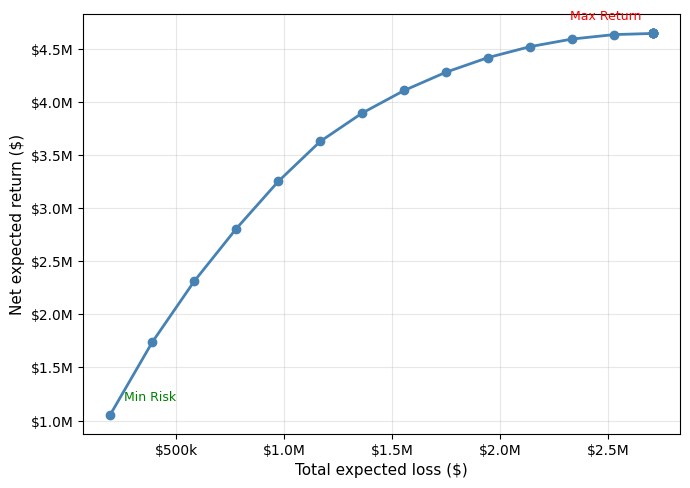

Saved pareto_frontier_EL.png


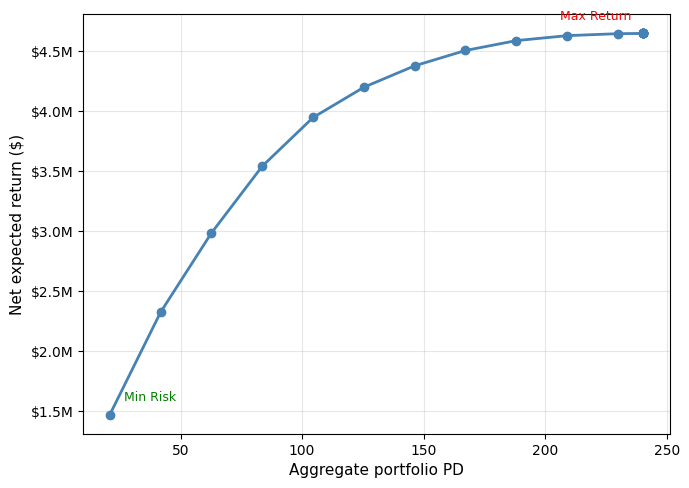

Saved pareto_frontier_PD.png


In [29]:
# ============================================================
# STEP 6: Visualize the Pareto frontier (EL vs PD scenarios)
# ============================================================

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

def money_formatter(v, _):
    if v >= 1e6:
        return f'${v/1e6:.1f}M'
    elif v >= 1e3:
        return f'${v/1e3:.0f}k'
    else:
        return f'${v:.0f}'

for df, label in [(pareto_EL, 'EL'), (pareto_PD, 'PD')]:
    fig, ax = plt.subplots(figsize=(7, 5))

    ax.plot(df['total_risk'], df['total_return'], 'o-', color='steelblue', lw=2)

    if label == 'EL':
        ax.set_xlabel('Total expected loss ($)', fontsize=11)
        ax.xaxis.set_major_formatter(FuncFormatter(money_formatter))
    else:
        ax.set_xlabel('Aggregate portfolio PD', fontsize=11)

    ax.set_ylabel('Net expected return ($)', fontsize=11)
    ax.yaxis.set_major_formatter(FuncFormatter(money_formatter))
    ax.grid(True, alpha=0.3)

    ax.annotate('Min Risk',
        xy=(df['total_risk'].iloc[0], df['total_return'].iloc[0]),
        xytext=(10, 10), textcoords='offset points', fontsize=9, color='green')
    ax.annotate('Max Return',
        xy=(df['total_risk'].iloc[-1], df['total_return'].iloc[-1]),
        xytext=(-60, 10), textcoords='offset points', fontsize=9, color='red')

    plt.tight_layout()
    fig.savefig(f'pareto_frontier_{label}.png', dpi=300, bbox_inches='tight',
                facecolor='white')
    plt.show()
    print(f"Saved pareto_frontier_{label}.png")

---
## 13. Performance Evaluation: BIP Optimiser vs Heuristic Baseline

We now compare the **exact BIP (ε-constraint)** method against the **traditional PD-threshold heuristic** across four metrics:

- **Total return** — raw dollar return for each method
- **Return-to-EL-risk efficiency** — return earned per dollar of expected loss taken on
- **Optimality gap** — how much return the heuristic leaves on the table vs the frontier
- **Pareto frontier overlay** — visual position of heuristic points relative to the BIP curve

The BIP frontier is used as the **gold standard**: for each heuristic portfolio we interpolate
what the optimizer would achieve at the *same* EL risk level, then measure the shortfall.



This is the central comparison of the thesis. For each heuristic portfolio (at PD thresholds 10 %, 15 %, 20 %, 25 %), we:

1. Compute the **optimality gap** — how much return the heuristic leaves on the table
2. Compare **efficiency ratios** (return ÷ EL risk) between methods
3. Overlay heuristic points on the Pareto frontier to visualise sub-optimality

The 2×2 dashboard summarises:
- **Panel 1:** Pareto frontier with heuristic scatter overlay
- **Panel 2:** Efficiency ratios (return per dollar of risk)
- **Panel 3:** Optimality gap in dollar terms
- **Panel 4:** Optimality gap as a percentage


PERFORMANCE EVALUATION  (returns are NET of expected loss)
Threshold  Loans H Net Ret ($) H EL Risk ($) BIP Net Ret ($)  Gap ($) Gap (%)
   PD<10%   1517    $2,136,766      $672,944      $2,540,415 $403,649   15.9%
   PD<15%   1687    $2,940,693    $1,094,560      $3,488,746 $548,053   15.7%
   PD<20%   1579    $3,503,228    $1,474,339      $4,019,193 $515,965   12.8%
   PD<25%   1485    $3,912,838    $1,769,924      $4,294,511 $381,673    8.9%


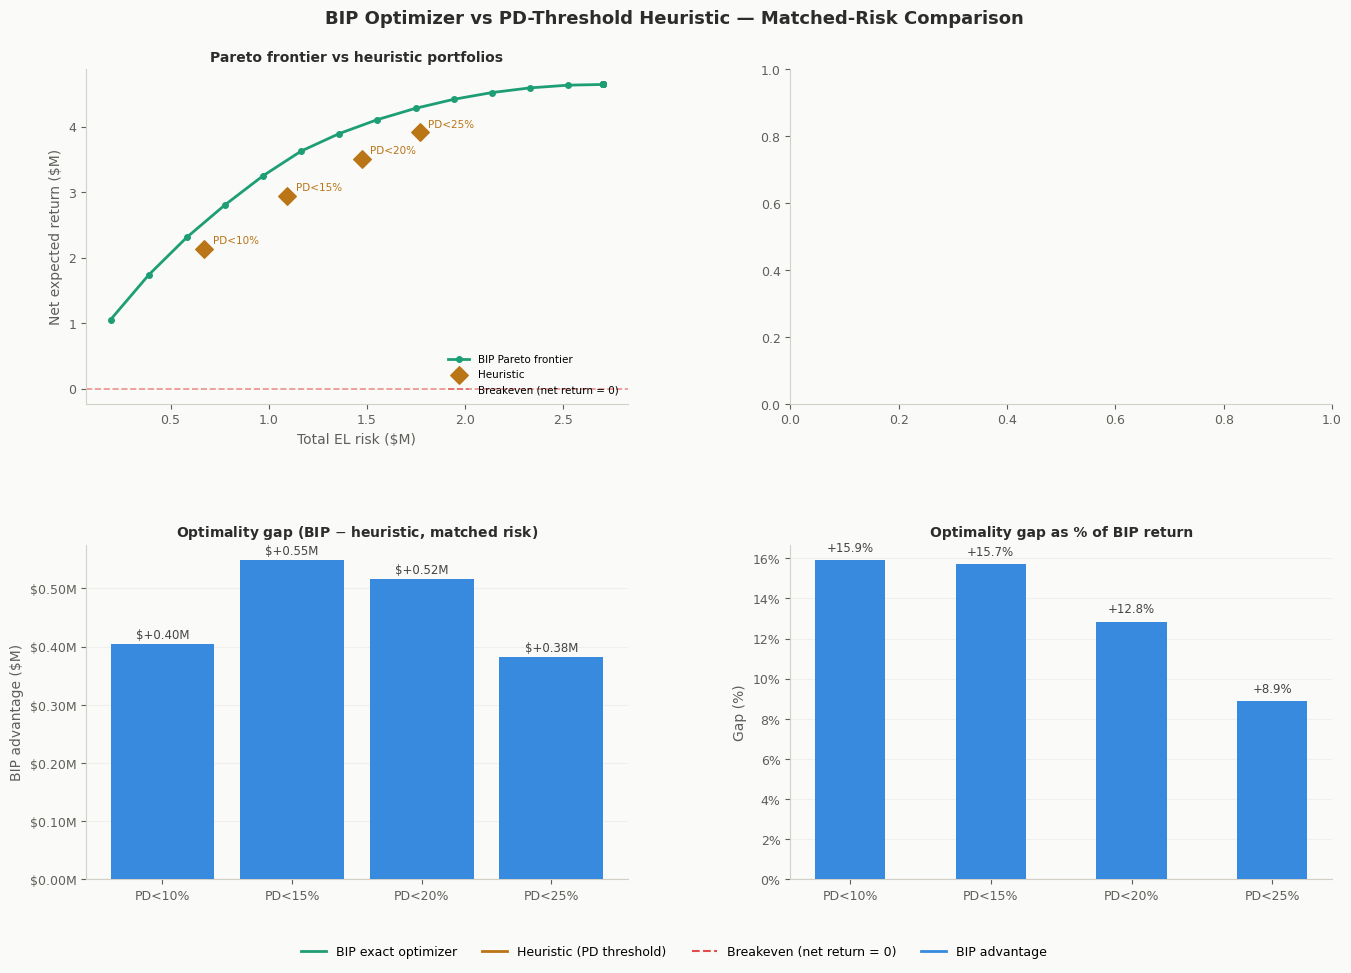

Saved: bip_vs_heuristic_evaluation.png


In [30]:
# ============================================================
# STEP 7: Performance Evaluation — BIP vs Heuristic
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

# ── 7a. Build heuristic results table ───────────────────────────────────────
thresholds = [0.10, 0.15, 0.20, 0.25]
heur_records = [
    heuristic_portfolio(loans, pd_threshold=t)
    for t in thresholds
]
heur_df = pd.DataFrame(heur_records)
heur_df['threshold_label'] = [f'PD<{int(t*100)}%' for t in thresholds]

# ── 7b. Interpolate BIP frontier return at each heuristic's EL ──────────────
def frontier_return_at_risk(frontier_df, query_risk):
    """
    Return BIP optimal net return at query_risk, by linear interpolation
    along the EL frontier. Matches the matched-risk protocol of §2.12.

    Returns NaN when query_risk falls outside the convex hull of the
    frontier's risk values — i.e. no extrapolation. A NaN here means the
    heuristic's risk level is one the BIP sweep did not cover, so the
    comparison at that point is undefined.
    """
    risks = frontier_df['total_risk'].values.astype(float)
    rets  = frontier_df['total_return'].values.astype(float)
    order = np.argsort(risks)
    risks, rets = risks[order], rets[order]
    if query_risk < risks[0] or query_risk > risks[-1]:
        return np.nan
    return float(np.interp(query_risk, risks, rets))

heur_df['bip_return_at_same_EL'] = heur_df['total_risk_EL'].apply(
    lambda r: frontier_return_at_risk(pareto_EL, r)
)
heur_df['optimality_gap_$']  = heur_df['bip_return_at_same_EL'] - heur_df['total_return']

# Gap-% uses the BIP return as the denominator, matching equation (2.17)
heur_df['optimality_gap_%']  = np.where(
    heur_df['bip_return_at_same_EL'] > 0,
    heur_df['optimality_gap_$'] / heur_df['bip_return_at_same_EL'] * 100,
    np.nan
)

# ── 7c. Print summary table ──────────────────────────────────────────────────
print('=' * 78)
print('PERFORMANCE EVALUATION  (returns are NET of expected loss)')
print('=' * 78)
summary_cols = [
    'threshold_label', 'n_approved', 'total_return',
    'total_risk_EL', 'bip_return_at_same_EL', 'optimality_gap_$', 'optimality_gap_%'
]
print(heur_df[summary_cols].rename(columns={
    'threshold_label'      : 'Threshold',
    'n_approved'           : 'Loans',
    'total_return'         : 'H Net Ret ($)',
    'total_risk_EL'        : 'H EL Risk ($)',
    'bip_return_at_same_EL': 'BIP Net Ret ($)',
    'optimality_gap_$'     : 'Gap ($)',
    'optimality_gap_%'     : 'Gap (%)',
}).to_string(index=False, formatters={
    'H Eff.': '{:.2f}'.format,
    **{c: '${:,.0f}'.format for c in
       ['H Net Ret ($)', 'H EL Risk ($)', 'BIP Net Ret ($)', 'Gap ($)']},
    'Gap (%)': '{:.1f}%'.format,
}))

# ── 7d. Plot — 2×2 comparison dashboard ─────────────────────────────────────
C = dict(bip='#1D9E75', heur='#BA7517', danger='#E24B4A',
         neutral='#888780', gap='#378ADD')

fig = plt.figure(figsize=(14, 10))
fig.patch.set_facecolor('#FAFAF8')
# 2×2 grid (was 2×3 — extra column left a gap)
gs = gridspec.GridSpec(2, 2, figure=fig,
                       hspace=0.42, wspace=0.30,
                       left=0.08, right=0.97, top=0.91, bottom=0.10)
axes = [fig.add_subplot(gs[r, c]) for r in range(2) for c in range(2)]
for ax in axes:
    ax.set_facecolor('#FAFAF8')
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_color('#D3D1C7')
    ax.tick_params(colors='#5F5E5A', labelsize=9)
    for lbl in [ax.xaxis.label, ax.yaxis.label]:
        lbl.set_color('#5F5E5A')

labels = heur_df['threshold_label'].tolist()
x, w   = np.arange(len(labels)), 0.38

# ── Panel 1 — Pareto frontier + heuristic scatter ──────────────────────────
ax = axes[0]
ax.plot(pareto_EL['total_risk'] / 1e6, pareto_EL['total_return'] / 1e6,
        '-o', color=C['bip'], lw=2, ms=4, label='BIP Pareto frontier')
ax.scatter(heur_df['total_risk_EL'] / 1e6, heur_df['total_return'] / 1e6,
           color=C['heur'], s=80, zorder=5, marker='D', label='Heuristic')
for _, row in heur_df.iterrows():
    ax.annotate(row['threshold_label'],
                xy=(row['total_risk_EL']/1e6, row['total_return']/1e6),
                xytext=(6, 4), textcoords='offset points',
                fontsize=7.5, color=C['heur'])
ax.axhline(0, color=C['danger'], lw=1.2, ls='--', alpha=0.6,
           label='Breakeven (net return = 0)')
ax.set_xlabel('Total EL risk ($M)')
ax.set_ylabel('Net expected return ($M)')
ax.set_title('Pareto frontier vs heuristic portfolios',
             fontsize=10, fontweight='bold', color='#2C2C2A')
ax.legend(fontsize=7.5, framealpha=0, loc='lower right')


# ── Panel 3 — Optimality gap $ ─────────────────────────────────────────────
ax = axes[2]
gaps = heur_df['optimality_gap_$'].values / 1e6
bar_colors = [C['gap'] if (not np.isnan(g) and g >= 0) else C['danger']
              for g in gaps]
bars = ax.bar(x, gaps, color=bar_colors, zorder=3, linewidth=0)
for bar, val in zip(bars, gaps):
    if np.isnan(val):
        ax.text(bar.get_x() + bar.get_width()/2, 0.005, 'n/a',
                ha='center', va='bottom', fontsize=8.5, color='#888780')
        continue
    va, offset = ('bottom', 0.005) if val >= 0 else ('top', -0.005)
    ax.text(bar.get_x() + bar.get_width()/2,
            val + offset,
            f'${val:+.2f}M',
            ha='center', va=va, fontsize=8.5, color='#444441')
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'${v:.2f}M'))
ax.axhline(0, color='#D3D1C7', lw=0.8)
ax.set_ylabel('BIP advantage ($M)')
ax.set_title('Optimality gap (BIP $-$ heuristic, matched risk)',
             fontsize=10, fontweight='bold', color='#2C2C2A')
ax.grid(axis='y', alpha=0.25, color='#D3D1C7')

# ── Panel 4 — Optimality gap % ─────────────────────────────────────────────
ax = axes[3]
gap_pct = heur_df['optimality_gap_%'].values
bar_colors_pct = [C['gap'] if (not np.isnan(g) and g >= 0) else C['danger']
                  for g in gap_pct]
bars_pct = ax.bar(x, gap_pct, color=bar_colors_pct,
                  zorder=3, width=0.5, linewidth=0)
for bar, val in zip(bars_pct, gap_pct):
    if np.isnan(val):
        ax.text(bar.get_x() + bar.get_width()/2, 0.3, 'n/a',
                ha='center', va='bottom', fontsize=8.5, color='#888780')
        continue
    va, offset = ('bottom', 0.3) if val >= 0 else ('top', -0.4)
    ax.text(bar.get_x() + bar.get_width()/2,
            val + offset,
            f'{val:+.1f}%', ha='center', va=va, fontsize=8.5, color='#444441')
ax.axhline(0, color='#D3D1C7', lw=0.8)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('Gap (%)')
ax.set_title('Optimality gap as % of BIP return',
             fontsize=10, fontweight='bold', color='#2C2C2A')
ax.grid(axis='y', alpha=0.25, color='#D3D1C7')

# ── Global title & legend ───────────────────────────────────────────────────
fig.suptitle(
    'BIP Optimizer vs PD-Threshold Heuristic — Matched-Risk Comparison',
    fontsize=13, fontweight='bold', color='#2C2C2A', y=0.97,
)
legend_elements = [
    Line2D([0],[0], color=C['bip'],    lw=2,            label='BIP exact optimizer'),
    Line2D([0],[0], color=C['heur'],   lw=2,            label='Heuristic (PD threshold)'),
    Line2D([0],[0], color=C['danger'], lw=1.5, ls='--', label='Breakeven (net return = 0)'),
    Line2D([0],[0], color=C['gap'],    lw=2,            label='BIP advantage'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=4,
           fontsize=9, framealpha=0, bbox_to_anchor=(0.5, 0.01))

plt.savefig('bip_vs_heuristic_evaluation.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('Saved: bip_vs_heuristic_evaluation.png')

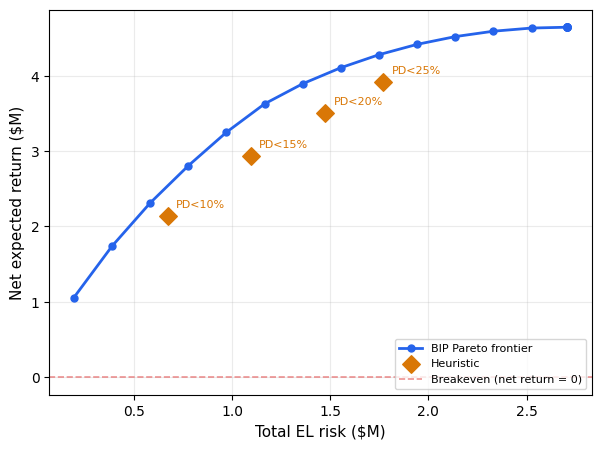

Saved pareto_vs_heuristic.png and .pdf


In [32]:
fig, ax = plt.subplots(figsize=(7, 5))

# Blue curve instead of green
ax.plot(pareto_EL['total_risk'] / 1e6, pareto_EL['total_return'] / 1e6,
        '-o', color='#2563EB', lw=2, ms=5, label='BIP Pareto frontier')

# Heuristic diamonds
ax.scatter(heur_df['total_risk_EL'] / 1e6, heur_df['total_return'] / 1e6,
           color='#D97706', s=80, zorder=5, marker='D', label='Heuristic')

# Labels on each diamond
for _, row in heur_df.iterrows():
    ax.annotate(row['threshold_label'],
                xy=(row['total_risk_EL']/1e6, row['total_return']/1e6),
                xytext=(6, 6), textcoords='offset points',
                fontsize=8, color='#D97706')

# Breakeven line
ax.axhline(0, color='#E24B4A', lw=1.2, ls='--', alpha=0.6,
           label='Breakeven (net return = 0)')

ax.set_xlabel('Total EL risk ($M)', fontsize=11)
ax.set_ylabel('Net expected return ($M)', fontsize=11)
ax.legend(fontsize=8, loc='lower right')
ax.grid(True, alpha=0.25)

fig.savefig('pareto_vs_heuristic.png', dpi=300, bbox_inches='tight',
            facecolor='white')
fig.savefig('pareto_vs_heuristic.pdf', bbox_inches='tight',
            facecolor='white')
plt.show()
print("Saved pareto_vs_heuristic.png and .pdf")